# This notebooks goes through different model candidates and selecting the best ones

In [1]:
import pandas as pd
import os, glob
from NSWData.NSWDataLoader import *
from ModelFiles.ModelPlots import *
from ModelFiles.ModelConfigs import HORIZONS
nsw_data_loader = NSWDataLoader()

Found NSW data path: C:\Users\kyim1\Desktop\capstone_project_GroupA\data\NSW


In [2]:
sarimax_folder = os.path.join(nsw_data_loader.output_dir, 'SARIMAX_tuning')
metrics_files = glob.glob(os.path.join(sarimax_folder, "*_fitting_log.csv"))
dfs = [pd.read_csv(f) for f in metrics_files]
sarimax_results_df = pd.concat(dfs, ignore_index=True)

gb_folder = os.path.join(nsw_data_loader.output_dir, 'gradient_boosting_tuning')
metrics_files = glob.glob(os.path.join(gb_folder, "*_fitting_log.csv"))
dfs = [pd.read_csv(f) for f in metrics_files]
gb_results_df = pd.concat(dfs, ignore_index=True)

lstm_folder = os.path.join(nsw_data_loader.output_dir, 'LSTM_tuning')
metrics_files = glob.glob(os.path.join(lstm_folder, "*_fitting_log.csv"))
dfs = [pd.read_csv(f) for f in metrics_files]
lstm_results_all_epochs_df = pd.concat(dfs, ignore_index=True)

patchtst_folder = os.path.join(nsw_data_loader.output_dir, 'PATCHTST_tuning')
metrics_files = glob.glob(os.path.join(patchtst_folder, "*_fitting_log.csv"))
dfs = [pd.read_csv(f) for f in metrics_files]
patchtst_results_all_epochs_df = pd.concat(dfs, ignore_index=True)

## Selecting the Best SARIMAX Model

In [3]:
sarimax_results_df = sarimax_results_df[['model_name','order','seasonal_order','time_taken_seconds','training_size','validation_horizon','validation_rmse']]

In [4]:
sarimax_results_df['training_size'].value_counts()

training_size
720      9
1440     9
2880     9
5760     9
11520    3
Name: count, dtype: int64

We have in total, 4 different (excl. 11520 as it was too big to run for higher order settings) training sizes (AKA input timesteps from the last timestep in training data).

We will iterate over below to find the best model:
* Retrieve best training_size for each model (order/seasonal_order)
* Compare models to retrieve the best model

In [5]:
best_sarimax_models_df = pd.DataFrame()
for horizon in HORIZONS:
    df = sarimax_results_df[sarimax_results_df['validation_horizon'] == horizon].copy()
    best_train_size_5 =  df[(df['order'] == '(5, 0, 0)') & (df['seasonal_order'] == '(1, 1, 1, 48)')].sort_values('validation_rmse').iloc[0]
    best_train_size_4 = df[(df['order'] == '(4, 0, 0)') & (df['seasonal_order'] == '(1, 1, 1, 48)')].sort_values('validation_rmse').iloc[0]
    best_train_size_3 = df[(df['order'] == '(3, 0, 0)') & (df['seasonal_order'] == '(1, 1, 1, 48)')].sort_values('validation_rmse').iloc[0]
    df = pd.concat([best_train_size_5, best_train_size_4, best_train_size_3], axis=1).T
    best_sarimax_models_df = pd.concat([best_sarimax_models_df, df], axis=0)
best_sarimax_models_df['rank_val_rmse'] = best_sarimax_models_df.groupby('validation_horizon')['validation_rmse'].rank().astype(int)
best_sarimax_models_df = best_sarimax_models_df.sort_values(['validation_horizon', 'rank_val_rmse'])
best_sarimax_models_df[['time_taken_seconds','validation_rmse']] = best_sarimax_models_df[['time_taken_seconds','validation_rmse']].apply(lambda x: round(x, 2))
best_sarimax_models_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_sarimax_models.csv'), index=False)
best_sarimax_models_df

,model_name,order,seasonal_order,time_taken_seconds,training_size,validation_horizon,validation_rmse,rank_val_rmse
2,sarimax_20260417_134746,"(5, 0, 0)","(1, 1, 1, 48)",262.28,1440,48,491.99,1
8,sarimax_20260417_172315,"(3, 0, 0)","(1, 1, 1, 48)",200.96,1440,48,498.38,2
9,sarimax_20260417_172703,"(4, 0, 0)","(1, 1, 1, 48)",217.99,1440,48,503.58,3
18,sarimax_20260418_012346,"(4, 0, 0)","(1, 1, 1, 48)",233.37,1440,336,647.65,1
17,sarimax_20260418_012346,"(3, 0, 0)","(1, 1, 1, 48)",225.33,1440,336,650.64,2
38,sarimax_20260418_080412,"(5, 0, 0)","(1, 1, 1, 48)",272.79,1440,336,656.29,3
28,sarimax_20260418_061643,"(4, 0, 0)","(1, 1, 1, 48)",225.56,1440,720,671.85,1
22,sarimax_20260418_051751,"(3, 0, 0)","(1, 1, 1, 48)",218.88,1440,720,675.56,2
32,sarimax_20260418_070759,"(5, 0, 0)","(1, 1, 1, 48)",154.0,720,720,682.88,3


Observations:
* the optimal training size is 1440 timesteps, which is 30 days.
* for horizon 48, non-seasonal autoregressive order = 5 had the best RMSE, but took the longest to fit.
* for horizons 336 and 720, non-seasonal autoregressive order = 4 has the best RMSE.

Despite performing the worst for horizon 48, the RMSE of model sarimax_20260417_172703 (the one with AR order 4) is 504, which is not too far away than the best RMSE of 492. The model also fits around 17% faster as well.

**Thus, to keep things simple, we will select order (4,0,0) and seasonal order (1,1,1,48) as our best model.**

## Selecting the best Gradient Boosting Model

In [6]:
gb_results_df = gb_results_df[['horizon','n_estimators','max_depth','learning_rate','rmse']]
gb_results_df.head()

,horizon,n_estimators,max_depth,learning_rate,rmse
0,336,600,3,0.10,516.805736
1,48,600,3,0.05,414.166463
2,48,600,3,0.10,388.848938
3,720,600,3,0.10,552.388622
4,336,600,3,0.05,535.662957


In [7]:
num_models_df = gb_results_df[['n_estimators','max_depth','learning_rate']].value_counts().reset_index()
num_models_df.drop(columns=['count'], inplace=True)
num_models_df.count()

n_estimators     18
max_depth        18
learning_rate    18
dtype: int64

There are 18 model candidates in total.

We will iterate over below to find the best model:
* find best learning_rate / depth for the best n_estimators 
    * if we only considered the best one for each horizon, most likely only the larger models remain, but we also want to see simpler models if performance is not too far off.
* analyze which model to use as best model

In [8]:
best_gb_models_df = pd.DataFrame()
for horizon in HORIZONS:
    df = gb_results_df[gb_results_df['horizon'] == horizon].copy()
    best_600_n_est_df = df[df['n_estimators'] == 600].sort_values('rmse').iloc[0]
    best_1000_n_est_df = df[df['n_estimators'] == 1000].sort_values('rmse').iloc[0]
    best_1200_n_est_df = df[df['n_estimators'] == 1200].sort_values('rmse').iloc[0]
    df = pd.concat([best_600_n_est_df, best_1000_n_est_df, best_1200_n_est_df], axis=1).T 
    df['rank_val_rmse'] = df['rmse'].rank().astype(int)
    best_gb_models_df = pd.concat([best_gb_models_df, df], axis=0)
best_gb_models_df = best_gb_models_df.sort_values(['horizon', 'rank_val_rmse'])
best_gb_models_df[['rmse']] = best_gb_models_df[['rmse']].apply(lambda x: round(x, 2))
best_gb_models_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_gb_models.csv'), index=False)
best_gb_models_df

,horizon,n_estimators,max_depth,learning_rate,rmse,rank_val_rmse
45,48.0,1200.0,5.0,0.1,382.25,1
18,48.0,1000.0,3.0,0.1,385.54,2
2,48.0,600.0,3.0,0.1,388.85,3
37,336.0,1200.0,3.0,0.1,513.04,1
19,336.0,1000.0,3.0,0.1,515.18,2
0,336.0,600.0,3.0,0.1,516.81,3
20,720.0,1000.0,3.0,0.1,550.90,1
38,720.0,1200.0,3.0,0.1,551.74,2
3,720.0,600.0,3.0,0.1,552.39,3


Indeed, **n_estimators=600 and max_depth=3 with learning_rate=0.1** has a very modest decrease in performance versus models much larger.

With Occam's Razor in mind, we choose this as the best gb model.

## Selecting the Best LSTM Model

In [9]:
lstm_best_model_df = lstm_results_all_epochs_df[lstm_results_all_epochs_df['best_epoch'] == lstm_results_all_epochs_df['epoch']]
lstm_best_model_df = lstm_best_model_df[['horizon','lookback','hidden_size','num_layers','dropout','num_attention_heads','val_loss','val_rmse']]

In [10]:
lstm_best_model_df.sort_values(['horizon', 'val_loss'], inplace=True)
lstm_best_model_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_lstm_models.csv'), index=False)
lstm_best_model_df

,horizon,lookback,hidden_size,num_layers,dropout,num_attention_heads,val_loss,val_rmse
60,48,168,128,2,0.20,4,0.114284,457.666542
222,48,168,256,4,0.35,8,0.125065,477.779717
157,336,336,128,2,0.20,4,0.254338,685.776367
248,336,336,256,4,0.35,8,0.301078,738.063323
186,720,720,128,2,0.20,4,0.344234,791.045593
272,720,720,256,4,0.35,8,0.350059,797.334672


Due to the lengthened time to train LSTM models on our hardware, we only compare 2 models:
1) "Large" with hidden_size=256, num_layers=4, num_attention_heads=8 and dropout=35%
2) "Small" with hidden_size=128, num_layers=2, num_attention_heads=4 and dropout=20%

We can already clearly see the "Small" model outperforms the "Large".

In [11]:
lstm_best_model_df = lstm_best_model_df.loc[[60, 157, 186]]
lstm_best_model_df

,horizon,lookback,hidden_size,num_layers,dropout,num_attention_heads,val_loss,val_rmse
60,48,168,128,2,0.2,4,0.114284,457.666542
157,336,336,128,2,0.2,4,0.254338,685.776367
186,720,720,128,2,0.2,4,0.344234,791.045593


#### Next, we will plot the learning curves

In [12]:
lstm_learning_df = lstm_results_all_epochs_df[['hidden_size','horizon','epoch','best_epoch','train_loss','val_loss']].copy()
lstm_learning_df = lstm_learning_df[lstm_learning_df['hidden_size'].isin(lstm_best_model_df['hidden_size'])]
lstm_learning_df.head()

,hidden_size,horizon,epoch,best_epoch,train_loss,val_loss
0,128,48,1,61,0.860872,0.579443
1,128,48,2,61,0.394589,0.329628
2,128,48,3,61,0.267333,0.264540
3,128,48,4,61,0.227976,0.233490
4,128,48,5,61,0.207135,0.208985


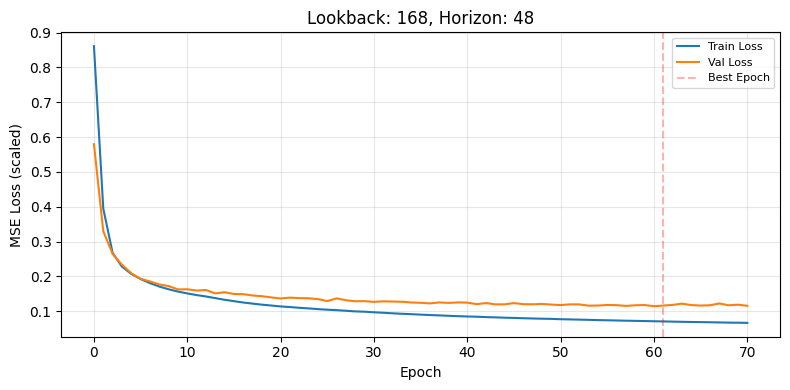

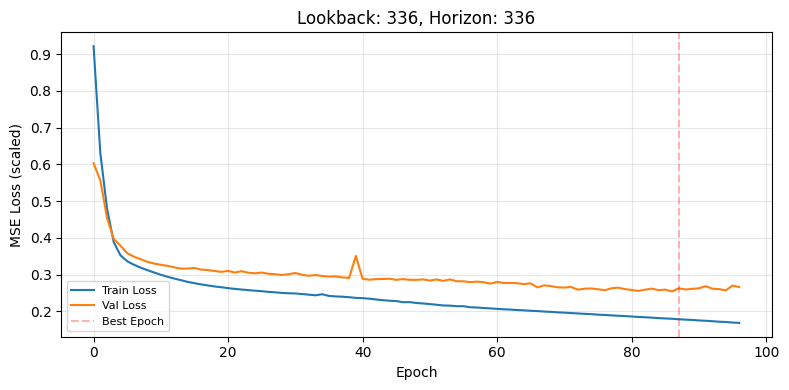

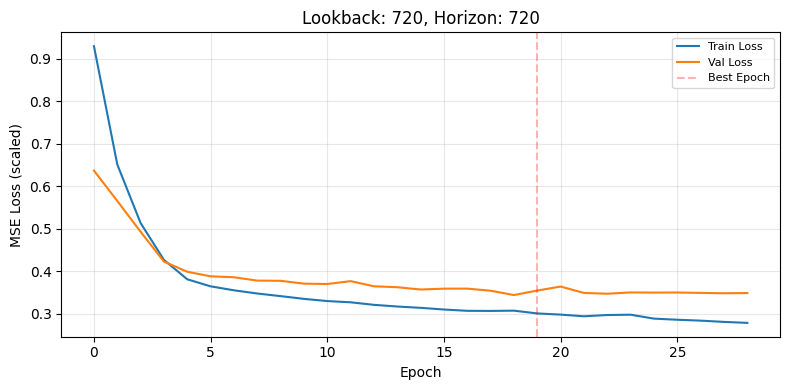

In [13]:
for row in lstm_best_model_df[['hidden_size','horizon','lookback']].drop_duplicates().itertuples():
    hidden_size = row.hidden_size
    horizon = row.horizon
    lookback = row.lookback
    plot_training_history(lstm_learning_df[(lstm_learning_df['hidden_size'] == hidden_size) & (lstm_learning_df['horizon'] == horizon)]['train_loss'].values,
                          lstm_learning_df[(lstm_learning_df['hidden_size'] == hidden_size) & (lstm_learning_df['horizon'] == horizon)]['val_loss'].values,
                          best_epoch=lstm_learning_df[(lstm_learning_df['hidden_size'] == hidden_size) & (lstm_learning_df['horizon'] == horizon)]['best_epoch'].values[0],
                          title=f"Lookback: {lookback}, Horizon: {horizon}")

## Selecting the Best PatchTST Model

In [14]:
patchtst_results_df = patchtst_results_all_epochs_df[['model_name','all_feature_cols','horizon','lookback','epoch','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate','validation_rmse','time_taken_seconds']].copy()
patchtst_results_univariate_df = patchtst_results_df[patchtst_results_df['all_feature_cols']=='[]'].copy()
# get best epoch from early stopping.
patchtst_results_univariate_df['rank_val_rmse'] = patchtst_results_univariate_df.groupby(['horizon','lookback','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate'])['validation_rmse'].rank().astype(int)
patchtst_results_univariate_df = patchtst_results_univariate_df[patchtst_results_univariate_df['rank_val_rmse']==1][['horizon','lookback','d_model','num_encoder_layers','dim_ff','dropout','learning_rate','validation_rmse','time_taken_seconds']]

patchtst_results_df = patchtst_results_df[patchtst_results_df['all_feature_cols']!='[]'][['model_name','all_feature_cols','horizon','lookback','epoch','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate','validation_rmse','time_taken_seconds']].copy()
# get best epoch from early stopping.
patchtst_results_df['rank_val_rmse'] = patchtst_results_df.groupby(['horizon','lookback','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate'])['validation_rmse'].rank().astype(int)
patchtst_results_df = patchtst_results_df[patchtst_results_df['rank_val_rmse']==1][['horizon','lookback','epoch','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate','validation_rmse','time_taken_seconds']]
patchtst_results_df.head()

,horizon,lookback,epoch,d_model,num_encoder_layers,num_attention_heads,dim_ff,dropout,learning_rate,validation_rmse,time_taken_seconds
36,48,336,37,128,3,16,256,0.2,0.000100,460.452511,48.618715
83,48,336,43,128,3,16,256,0.0,0.000005,413.641477,48.535944
99,48,336,6,512,5,16,2048,0.2,0.000100,461.197867,211.940539
136,48,336,27,512,5,16,2048,0.0,0.000005,406.138819,206.400724
164,48,720,18,128,3,16,256,0.2,0.000100,461.227812,64.944432


In [15]:
num_models_df = patchtst_results_df[['lookback','d_model','num_encoder_layers','num_attention_heads','dim_ff','dropout','learning_rate']].value_counts().reset_index()
num_models_df.drop(columns=['count'], inplace=True)
num_models_df

,lookback,d_model,num_encoder_layers,num_attention_heads,dim_ff,dropout,learning_rate
0,336,128,3,16,256,0.2,0.000100
1,336,128,3,16,256,0.0,0.000005
2,336,512,5,16,2048,0.2,0.000100
3,336,512,5,16,2048,0.0,0.000005
4,720,128,3,16,256,0.2,0.000100
5,720,128,3,16,256,0.0,0.000005
6,720,512,5,16,2048,0.2,0.000100
7,720,512,5,16,2048,0.0,0.000005


We have 8 model candidates for each horizon.

In [16]:
best_patchtst_models_df = pd.DataFrame()
for horizon in HORIZONS:
    _df = patchtst_results_df[patchtst_results_df['horizon'] == horizon].copy()
    for row in num_models_df.itertuples():
        _df_lb = _df[(_df['lookback'] == row.lookback) & 
                    (_df['d_model'] == row.d_model) & 
                    (_df['num_encoder_layers'] == row.num_encoder_layers) & 
                    (_df['num_attention_heads'] == row.num_attention_heads) & 
                    (_df['dim_ff'] == row.dim_ff) & 
                    (_df['dropout'] == row.dropout) & 
                    (_df['learning_rate'] == row.learning_rate)].sort_values('validation_rmse').iloc[0]
        best_patchtst_models_df = pd.concat([best_patchtst_models_df, _df_lb.to_frame().T], axis=0)
best_patchtst_models_df['rank_val_rmse'] = best_patchtst_models_df.groupby('horizon')['validation_rmse'].rank().astype(int)
best_patchtst_models_df = best_patchtst_models_df.sort_values(['horizon', 'rank_val_rmse'])
best_patchtst_models_df[['time_taken_seconds','validation_rmse']] = best_patchtst_models_df[['time_taken_seconds','validation_rmse']].apply(lambda x: round(x, 2))
best_patchtst_models_df = best_patchtst_models_df.drop(columns=['epoch','num_attention_heads'])
best_patchtst_models_df = best_patchtst_models_df.astype({'horizon': int, 'lookback': int, 
                                                          'd_model': int, 'num_encoder_layers': int, 
                                                          'dim_ff': int, 'dropout': float, 'learning_rate': float, 
                                                          'validation_rmse': float, 'time_taken_seconds': float})
best_patchtst_models_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_patchtst_models_df.csv'), index=False)
best_patchtst_models_df

,horizon,lookback,d_model,num_encoder_layers,dim_ff,dropout,learning_rate,validation_rmse,time_taken_seconds,rank_val_rmse
136,48,336,512,5,2048,0.0,0.000005,406.14,206.40,1
236,48,720,128,3,256,0.0,0.000005,411.97,63.13,2
83,48,336,128,3,256,0.0,0.000005,413.64,48.54,3
282,48,720,512,5,2048,0.0,0.000005,414.71,436.48,4
36,48,336,128,3,256,0.2,0.000100,460.45,48.62,5
99,48,336,512,5,2048,0.2,0.000100,461.20,211.94,6
164,48,720,128,3,256,0.2,0.000100,461.23,64.94,7
253,48,720,512,5,2048,0.2,0.000100,470.61,448.61,8
376,336,336,512,5,2048,0.0,0.000005,597.30,207.74,1
460,336,720,512,5,2048,0.0,0.000005,602.79,441.29,2


All models with non-zero dropout & higher learning rate performs less good than its 0% dropout and smaller learning rate counterparts.

We remove them from the pool.

In [17]:
best_patchtst_models_df = best_patchtst_models_df[best_patchtst_models_df['dropout'] == 0.0]
best_patchtst_models_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_patchtst_models_filtered_df.csv'), index=False)
best_patchtst_models_df

,horizon,lookback,d_model,num_encoder_layers,dim_ff,dropout,learning_rate,validation_rmse,time_taken_seconds,rank_val_rmse
136,48,336,512,5,2048,0.0,0.000005,406.14,206.40,1
236,48,720,128,3,256,0.0,0.000005,411.97,63.13,2
83,48,336,128,3,256,0.0,0.000005,413.64,48.54,3
282,48,720,512,5,2048,0.0,0.000005,414.71,436.48,4
376,336,336,512,5,2048,0.0,0.000005,597.30,207.74,1
460,336,720,512,5,2048,0.0,0.000005,602.79,441.29,2
425,336,720,128,3,256,0.0,0.000005,604.32,64.53,3
335,336,336,128,3,256,0.0,0.000005,609.56,48.75,4
533,720,336,128,3,256,0.0,0.000005,634.88,50.39,1
568,720,336,512,5,2048,0.0,0.000005,634.96,211.50,2


**For horizons 48,** the top model is the larger model (one with d_model 512) with 336 lookback. The second place is the smaller model (d_model 128) with 720 lookback.<br>
However, the larger model also takes 3-4 times longer to train while being around 25 times larger in terms of number of parameters (small models has 663,091 while the large model has 16,824,373 parameters) than the second place small model.<br><br>As their RMSEs are very close, the reasonable choice is the smaller model with d_model=256 with 720 lookback window (i.e. index 236).

**For horizons 336,** the story is the same as 48. With the larger models (d_model 512 and lookback 336 & 720) only about 2-7 RMSEs apart with the small but with much longer run times, the reasonable choice is also the smaller model (i.e. index 425).


**For horizon 720,** the smaller model beats the larger models, therefore we use the smaller model (i.e. index 533) with lookback window 720. This is basically the original configuration of PatchTST\42 by Nie et al. (2023) but with 0% dropout.

In summary, for horizons:
* 48 & 336, use model with d_model=128 & lookback=720 (index 236, 425)
* 720, use model with d_model=128 & lookback=336 (index 533)

In [18]:
best_patchtst_models_df = best_patchtst_models_df.loc[[236, 425, 533]]
best_patchtst_models_df

,horizon,lookback,d_model,num_encoder_layers,dim_ff,dropout,learning_rate,validation_rmse,time_taken_seconds,rank_val_rmse
236,48,720,128,3,256,0.0,0.000005,411.97,63.13,2
425,336,720,128,3,256,0.0,0.000005,604.32,64.53,3
533,720,336,128,3,256,0.0,0.000005,634.88,50.39,1


We also take a look at the univariate case and compare with above.

In [19]:
patchtst_results_univariate_df['rank_val_rmse'] = patchtst_results_univariate_df.groupby(['horizon'])['validation_rmse'].rank().astype(int)
patchtst_results_univariate_df.sort_values(['horizon', 'rank_val_rmse'], inplace=True)
patchtst_results_univariate_df[['validation_rmse','time_taken_seconds']] = patchtst_results_univariate_df[['validation_rmse','time_taken_seconds']].apply(lambda x: round(x, 2))
patchtst_results_univariate_df.to_csv(os.path.join(nsw_data_loader.output_dir, '..', 'report', 'tables', 'best_patchtst_univariate_models.csv'), index=False)
patchtst_results_univariate_df

,horizon,lookback,d_model,num_encoder_layers,dim_ff,dropout,learning_rate,validation_rmse,time_taken_seconds,rank_val_rmse
750,48,720,128,3,256,0.0,0.000005,413.36,51.67,1
701,48,336,128,3,256,0.0,0.000005,417.01,48.95,2
819,336,720,128,3,256,0.0,0.000005,609.27,51.95,1
786,336,336,128,3,256,0.0,0.000005,615.93,50.58,2
869,720,336,128,3,256,0.0,0.000005,644.78,50.04,1
893,720,720,128,3,256,0.0,0.000005,660.35,50.91,2


Small detrimental effect when only fitting on the target variable.

#### Next, we will plot the learning curves

In [20]:
patchtst_results_all_epochs_df.head()

,model_name,lookback_window,epoch,training_loss,validation_loss,validation_horizon,validation_rmse,validation_mse,time_taken_seconds,model_type,...,num_encoder_layers,num_attention_heads,dim_ff,dropout,dropout_head_fc,use_norm,activation,learning_rate,seed,num_parameters
0,patchtst_20260417_150738,336,1,0.359921,0.155869,48,533.581436,284709.148758,49.402999,patchtst,...,3,16,256,0.2,0.2,True,gelu,0.0001,31415,NaN
1,patchtst_20260417_150738,336,2,0.282729,0.145282,48,512.003035,262147.107904,49.132551,patchtst,...,3,16,256,0.2,0.2,True,gelu,0.0001,31415,NaN
2,patchtst_20260417_150738,336,3,0.269894,0.145291,48,509.083875,259166.391419,49.410555,patchtst,...,3,16,256,0.2,0.2,True,gelu,0.0001,31415,NaN
3,patchtst_20260417_150738,336,4,0.262211,0.142851,48,510.560765,260672.294842,49.694096,patchtst,...,3,16,256,0.2,0.2,True,gelu,0.0001,31415,NaN
4,patchtst_20260417_150738,336,5,0.256016,0.139468,48,503.994070,254010.022827,49.855347,patchtst,...,3,16,256,0.2,0.2,True,gelu,0.0001,31415,NaN


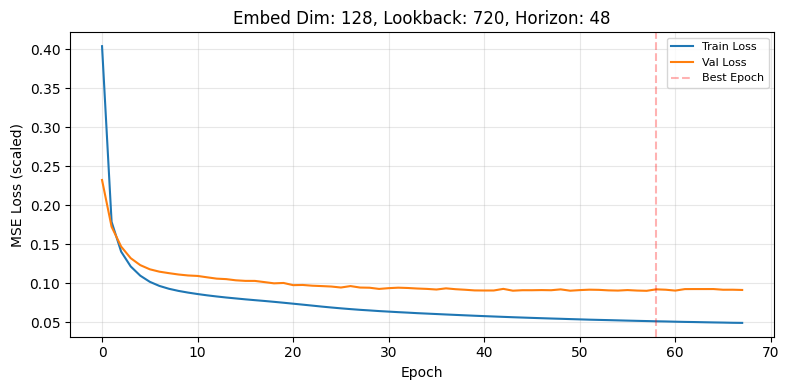

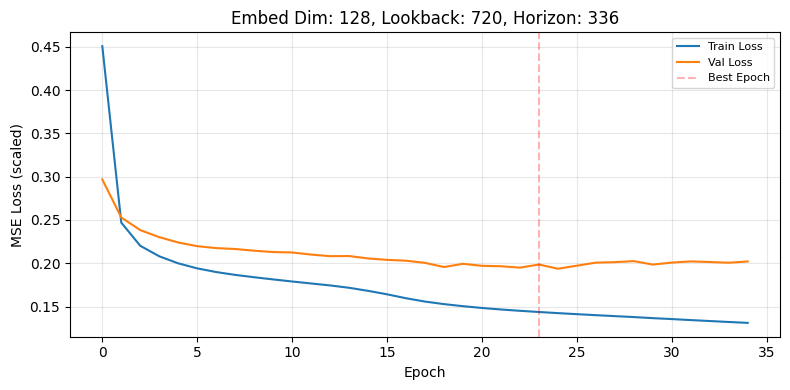

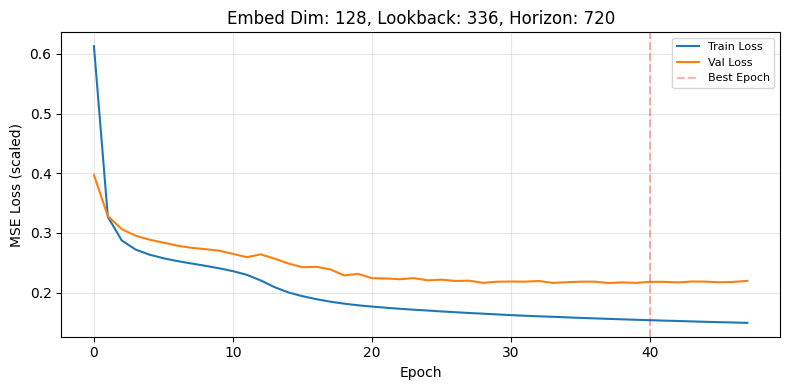

In [21]:
for idx in best_patchtst_models_df.index:
    row = patchtst_results_all_epochs_df.loc[idx]
    model_name = row.model_name
    d_model = row.d_model
    lookback = row.lookback
    horizon = row.horizon
    _df = patchtst_results_all_epochs_df[(patchtst_results_all_epochs_df['model_name'] == model_name)].copy()   
    plot_training_history(_df.sort_values('epoch')['training_loss'].values,
                          _df.sort_values('epoch')['validation_loss'].values,
                          best_epoch=_df.sort_values('epoch')['epoch'].values[np.argmin(_df.sort_values('epoch')['validation_rmse'].values)],
                          title=f"Embed Dim: {d_model}, Lookback: {lookback}, Horizon: {horizon}")